In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
import cv2

In [2]:
def load_spectrograms(root_dir):
  IMG_WIDTH  = 432
  IMG_HEIGHT = 288

  x = []
  y = []

  class_names = sorted(os.listdir(root_dir))


  for label, class_name in enumerate(class_names):
      class_path = os.path.join(root_dir, class_name)

      if not os.path.isdir(class_path):
          continue

      for img_name in os.listdir(class_path):
          img_path = os.path.join(class_path, img_name)

          # lecture image
          img = cv2.imread(img_path)

          if img is None:
              continue

          # resize (sécurité)
          img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))

          x.append(img)
          y.append(label)

  # conversion LIST → NUMPY ARRAY (CRUCIAL)
  x = np.array(x, dtype=np.float32)
  y = np.array(y, dtype=np.int32)

  print("x shape:", x.shape)
  print("y shape:", y.shape)
  print("classes:", class_names)
  return x, y

Chargement des données depuis le drive

In [3]:
from google.colab import drive
drive.mount('/content/drive')

path = "/content/drive/MyDrive/images_original"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
x, y = load_spectrograms(path)

x shape: (999, 288, 432, 3)
y shape: (999,)
classes: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']


In [5]:
print(np.unique(y))

[0 1 2 3 4 5 6 7 8 9]


In [6]:
from keras.utils import to_categorical
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    stratify=y,
    test_size=0.3,
    random_state=0
)

x_train = np.array(x_train)
x_test  = np.array(x_test)

x_train = x_train.mean(axis=-1, keepdims=True)
x_test  = x_test.mean(axis=-1, keepdims=True)

# Normalisation
x_train = x_train / 255.0
x_test = x_test / 255.0

# Labels one-hot
y_train_encoded = to_categorical(y_train, 10)
y_test_encoded  = to_categorical(y_test, 10)

print(x_train.shape)
print(y_train_encoded.shape)

print("Min x_train:", x_train.min())
print("Max x_train:", x_train.max())
print("Mean x_train:", x_train.mean())
print("Std x_train:", x_train.std())

(699, 288, 432, 1)
(699, 10)
Min x_train: 0.0
Max x_train: 1.0
Mean x_train: 0.48371112
Std x_train: 0.45070344


In [7]:
print("Distribution des labels dans y_train :")
print(np.unique(y_train, return_counts=True))

print("\nPremiers labels :")
print(y_train[:20])

print("\nShape y_train_encoded :")
print(y_train_encoded[:5])

Distribution des labels dans y_train :
(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=int32), array([70, 70, 70, 70, 70, 69, 70, 70, 70, 70]))

Premiers labels :
[1 2 2 6 2 0 2 7 1 2 8 4 4 2 6 7 6 5 1 8]

Shape y_train_encoded :
[[0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]]


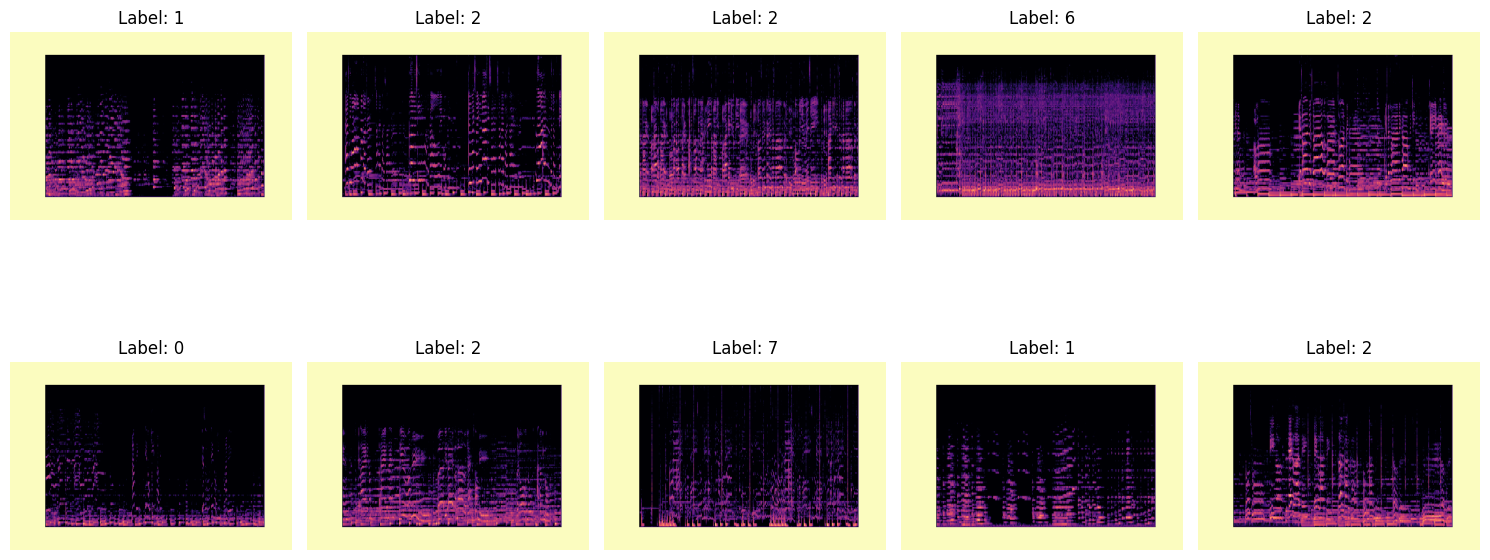

In [8]:
# AFFICHE 10 IMAGES APRÈS NORMALISATION :
plt.figure(figsize=(15, 8))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_train[i].squeeze(), cmap='magma')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

In [48]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    # Bloc 1
    Conv2D(64, (3,3), activation='relu', padding='same', input_shape=(288, 432, 1)),
    MaxPooling2D((2,2)),

    # Bloc 2
    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),

    # Bloc 3
    Conv2D(128, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()  # Regarde le nombre de paramètres

Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_77 (Conv2D)              │ (None, 288, 432, 64)   │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_63 (MaxPooling2D) │ (None, 144, 216, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_78 (Conv2D)              │ (None, 144, 216, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_64 (MaxPooling2D) │ (None, 72, 108, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_79 (Conv2D)              │ (None, 72, 108, 128)   │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_65 (MaxPooling2D) │ (None, 36, 54, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_17 (Flatten)            │ (None, 248832)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 128)            │    31,850,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_81 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,963,338 (121.93 MB)

 Trainable params: 31,963,338 (121.93 MB)

 Non-trainable params: 0 (0.00 B)

Entrainement

In [49]:
hist = model.fit(
    x_train, y_train_encoded,
    validation_data=(x_test, y_test_encoded),
    batch_size=32,
    epochs=10,
    shuffle=True,
    verbose=1
)

Epoch 1/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 11s 364ms/step - accuracy: 0.0960 - loss: 3.2492 - val_accuracy: 0.1567 - val_loss: 2.2711
Epoch 2/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 191ms/step - accuracy: 0.1634 - loss: 2.2549 - val_accuracy: 0.2367 - val_loss: 2.0951
Epoch 3/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 206ms/step - accuracy: 0.2321 - loss: 2.0709 - val_accuracy: 0.3567 - val_loss: 1.8439
Epoch 4/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 205ms/step - accuracy: 0.3717 - loss: 1.8310 - val_accuracy: 0.3767 - val_loss: 1.6274
Epoch 5/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 193ms/step - accuracy: 0.4217 - loss: 1.6169 - val_accuracy: 0.4833 - val_loss: 1.4635
Epoch 6/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 197ms/step - accuracy: 0.5095 - loss: 1.4018 - val_accuracy: 0.5133 - val_loss: 1.4027
Epoch 7/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 195ms/step - accuracy: 0.5594 - loss: 1.2481 - val_accuracy: 0.5800 - val_loss: 1.2041
Epoch 8/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 195ms/step - accuracy: 0.6521 - loss: 0.9678 - val_accuracy: 0

In [50]:
final_train_acc = hist.history['accuracy'][-1]
final_val_acc = hist.history['val_accuracy'][-1]

print(f"Accuracy finale training: {final_train_acc:.2%}")
print(f"Accuracy finale validation: {final_val_acc:.2%}")

Accuracy finale training: 81.83%
Accuracy finale validation: 59.33%
